[reference](https://medium.com/@alexrodriguesj/sentiment-analysis-with-bert-a-comprehensive-guide-6d4d091eb6bb#38ec)

In [1]:
!pip install pandas transformers torch datasets kaggle
!pip install spacy nltk
!pip install matplotlib seaborn

In [2]:
!kaggle datasets download -d crowdflower/twitter-airline-sentiment
!unzip -o twitter-airline-sentiment.zip -d twitter_airline_sentiment

Dataset URL: https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment
License(s): CC-BY-NC-SA-4.0
100% 2.55M/2.55M [00:00<00:00, 3.74MB/s]

Archive:  twitter-airline-sentiment.zip
  inflating: twitter_airline_sentiment/Tweets.csv  
  inflating: twitter_airline_sentiment/database.sqlite  


# Data Collection

In [3]:
import pandas as pd

data = pd.read_csv('twitter_airline_sentiment/Tweets.csv') # Load the dataset

data.head() # Display the first few rows

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [4]:
data.shape

(14640, 15)

In [5]:
data = data[:3000]
data.shape

(3000, 15)

In [6]:
import spacy
import nltk
from nltk.corpus import stopwords
import string

# Load spaCy model
nlp = spacy.load('en_core_web_sm')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def preprocess_text(text):

    text = text.lower() # Convert to lowercase

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenize and lemmatize
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc if token.text not in stop_words]
    return ' '.join(tokens)

data['cleaned_text'] = data['text'].apply(preprocess_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [7]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 109.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


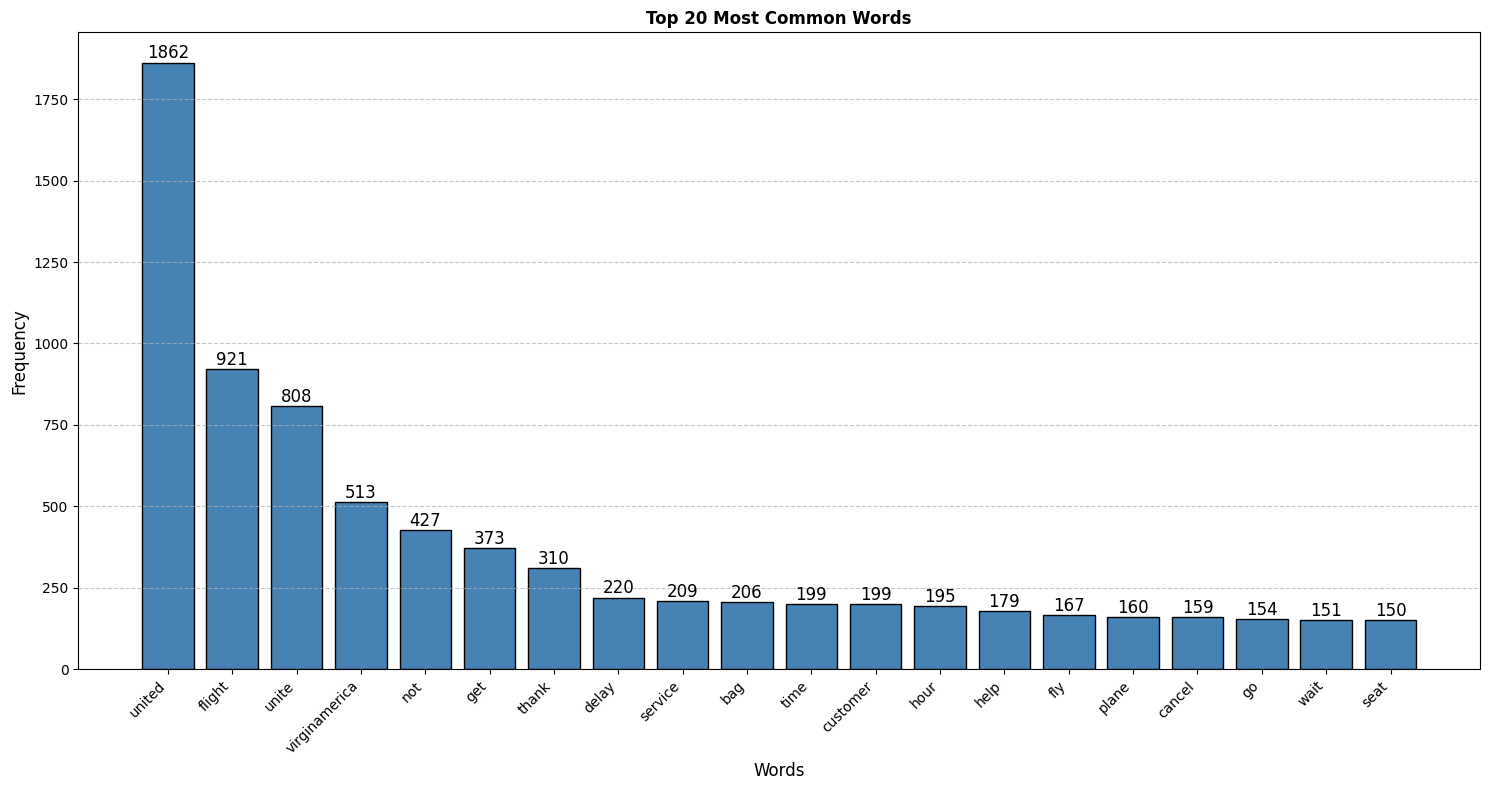

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example of a word frequency plot
from collections import Counter

all_words = ' '.join(data['cleaned_text']).split()
word_freq = Counter(all_words)
common_words = word_freq.most_common(20)

words = [word[0] for word in common_words]
counts = [word[1] for word in common_words]

plt.figure(figsize=(15, 8))
bars = plt.bar(words, counts, color='steelblue', edgecolor='black')

plt.title('Top 20 Most Common Words', fontsize=12, fontweight='bold')
plt.xlabel('Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval), ha='center', va='bottom', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [9]:
# Map labels to integers
label_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}
data['label'] = data['airline_sentiment'].map(label_mapping)

In [10]:
from transformers import BertTokenizer

# Tokenization
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Tokenize the data
def tokenize_function(text):
    return tokenizer(text, padding='max_length', truncation=True, max_length=128)

data['tokenized'] = data['cleaned_text'].apply(tokenize_function)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [11]:
data[["label","tokenized"]].head()

,label,tokenized
0,1,"[input_ids, token_type_ids, attention_mask]"
1,2,"[input_ids, token_type_ids, attention_mask]"
2,1,"[input_ids, token_type_ids, attention_mask]"
3,0,"[input_ids, token_type_ids, attention_mask]"
4,0,"[input_ids, token_type_ids, attention_mask]"


In [12]:
import torch

class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.encodings['input_ids'])

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

In [13]:
from sklearn.model_selection import train_test_split

# Split the dataset
train_texts, temp_texts, train_labels, temp_labels = train_test_split(data['tokenized'].to_list(), data['label'].to_list(), test_size=0.3, random_state=42)
val_texts, test_texts, val_labels, test_labels = train_test_split(temp_texts, temp_labels, test_size=0.5, random_state=42)

In [14]:
def convert_to_dicts(tokenized_texts):
    input_ids = [d['input_ids'] for d in tokenized_texts]
    attention_masks = [d['attention_mask'] for d in tokenized_texts]
    return {'input_ids': input_ids, 'attention_mask': attention_masks}

# Convert to lists of dictionaries
train_encodings = convert_to_dicts(train_texts)
val_encodings = convert_to_dicts(val_texts)
test_encodings = convert_to_dicts(test_texts)

# Create three dataset objects using the SentimentDataset
train_dataset = SentimentDataset(train_encodings, train_labels)
val_dataset = SentimentDataset(val_encodings, val_labels)
test_dataset = SentimentDataset(test_encodings, test_labels)

In [15]:
train_dataset[:5]

{'input_ids': tensor([[  101, 15908, 10166,  3066,  2382,  4606,  2835,  2800,  3733,  2689,
           2191,  8013,  3407,   102,     0,     0,     0,     0,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0,    

In [16]:
from transformers import BertForSequenceClassification, Trainer, TrainingArguments

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [17]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='./results', # All files generated during training will be stored here
    num_train_epochs=3, # The model will be trained for 3 full epochs unless the step limit (max_steps) is reached first
    per_device_train_batch_size=5, # Training batch size per device (GPU or CPU).
    per_device_eval_batch_size=5, # Evaluation batch size per device (GPU or CPU).
    warmup_steps=10, # Number of warm-up steps during which the learning rate gradually increases to its initial value
    weight_decay=0.01, # Weight decay rate: this technique helps to avoid overfitting, penalizing large weights in the neural network
    logging_dir='./logs', # Directory where training logs will be stored
    max_steps=10,  # Maximum number of training steps to be performed
    save_steps=2,  # Range of steps after which the model will be saved
    logging_steps=2,  # Range of steps after which log information will be recorded
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [18]:
trainer = Trainer(
    model=model, # The pre-trained model that you want to fine-tune or train
    args=training_args, # The training arguments that specify the configurations for the training process
    train_dataset=train_dataset, # The dataset used for training the model
    eval_dataset=val_dataset # The dataset used for evaluating the model during training
)

# Start training
trainer.train()

Step,Training Loss
2,1.414716
4,1.250961
6,1.082494
8,1.228698
10,1.100154


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=10, training_loss=1.2154048919677733, metrics={'train_runtime': 59.242, 'train_samples_per_second': 0.844, 'train_steps_per_second': 0.169, 'total_flos': 3288917721600.0, 'train_loss': 1.2154048919677733, 'epoch': 0.023809523809523808})

In [19]:
# Evaluate the Model
results = trainer.evaluate(test_dataset)

print("Evaluation Results:")
print(f"  - Loss: {results['eval_loss']:.4f}")
print(f"  - Runtime: {results['eval_runtime']:.2f} seconds")
print(f"  - Samples per Second: {results['eval_samples_per_second']:.2f}")
print(f"  - Steps per Second: {results['eval_steps_per_second']:.2f}")
print(f"  - Epoch: {results['epoch']:.4f}")

Evaluation Results:
  - Loss: 1.0573
  - Runtime: 3.10 seconds
  - Samples per Second: 145.29
  - Steps per Second: 29.06
  - Epoch: 0.0238


In [20]:
# Save the model and tokenizer in the current folder
model_save_path = "./"
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./tokenizer_config.json', './tokenizer.json')

In [22]:
torch.cuda.is_available()

True

In [28]:
torch.cuda.get_device_name()

'Tesla T4'

In [31]:
def predict_sentiment(text):
    '''Function to predict the sentiment of a given text using a pre-trained BERT model.
    Args: the input text for sentiment prediction.
    Returns: the predicted sentiment ('negative', 'neutral', 'positive').
    '''
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    outputs = model(**inputs)
    predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
    predicted_class = torch.argmax(predictions, dim=1).item()
    sentiment = {0: 'negative', 1: 'neutral', 2: 'positive'}
    return sentiment[predicted_class]

# Example prediction
example_text = "I hate flying with this airline!"
predicted_sentiment = predict_sentiment(example_text)
print(f"Predicted Sentiment: {predicted_sentiment}")

Predicted Sentiment: neutral
